# Pix2Pix Comic Face Generation with Hyperparameter Tuning

**Production-grade implementation** of conditional GAN for real-to-comic face translation.

- **Architecture**: U-Net generator + PatchGAN discriminator
- **Hyperparameter Tuning**: Grid search over 27 configurations (LR × Batch Size × Lambda L1)
- **Checkpointing**: Periodic (every N epochs) + Best model (via FID score)
- **Metrics**: Discriminator loss, Generator loss, FID (Fréchet Inception Distance)
- **Hardware**: Auto-detect CUDA/MPS/CPU with mixed-precision training (AMP) on CUDA

In [8]:
import os
import sys
import time
import json
import random
import csv
from pathlib import Path
from itertools import product
from typing import Tuple, Dict, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from PIL import Image
import matplotlib.pyplot as plt

# For FID calculation
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    HAS_TORCHMETRICS = True
except ImportError:
    HAS_TORCHMETRICS = False

# Add src to path
sys.path.insert(0, str(Path("..").resolve()))

print("✓ All imports successful")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ TorchMetrics FID available: {HAS_TORCHMETRICS}")

✓ All imports successful
✓ PyTorch version: 2.5.1+cu121
✓ TorchMetrics FID available: True


## 1. Configuration & Setup

In [9]:
# ── Global Settings ──
IMAGE_SIZE = 64
SEED = 42

# ── Paths ──
DATA_DIR = Path("../data/split")
TRAIN_REAL_DIR = DATA_DIR / "train" / "real"
TRAIN_COMIC_DIR = DATA_DIR / "train" / "comic"
VAL_REAL_DIR = DATA_DIR / "val" / "real"
VAL_COMIC_DIR = DATA_DIR / "val" / "comic"

CHECKPOINT_DIR = Path("../checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

LOG_DIR = Path("../logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ──
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    torch.backends.cudnn.benchmark = True
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

USE_AMP = DEVICE.type == "cuda"

# ── Reproducibility ──
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == "cuda":
    torch.cuda.manual_seed_all(SEED)

print(f"✓ Device: {DEVICE}")
print(f"✓ AMP enabled: {USE_AMP}")
print(f"✓ Image size: {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"✓ Data paths:")
print(f"  Train real:  {TRAIN_REAL_DIR}")
print(f"  Train comic: {TRAIN_COMIC_DIR}")
print(f"  Val real:    {VAL_REAL_DIR}")
print(f"  Val comic:   {VAL_COMIC_DIR}")
print(f"✓ Checkpoint dir: {CHECKPOINT_DIR}")


✓ Device: cuda
✓ AMP enabled: True
✓ Image size: 64×64
✓ Data paths:
  Train real:  ..\data\split\train\real
  Train comic: ..\data\split\train\comic
  Val real:    ..\data\split\val\real
  Val comic:   ..\data\split\val\comic
✓ Checkpoint dir: ..\checkpoints


## 2. Dataset & DataLoader

In [10]:
IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


class PairedFaceDataset(Dataset):
    """Paired real-to-comic face dataset."""
    
    def __init__(self, real_dir: Path, comic_dir: Path, image_size: int = 64):
        self.real_dir = Path(real_dir)
        self.comic_dir = Path(comic_dir)
        self.image_size = image_size
        
        # Get sorted list of real images
        self.real_files = sorted(
            [f for f in self.real_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS]
        )
        
        # Get sorted list of comic images
        self.comic_files = sorted(
            [f for f in self.comic_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS]
        )
        
        # Ensure same number of pairs
        n_pairs = min(len(self.real_files), len(self.comic_files))
        self.real_files = self.real_files[:n_pairs]
        self.comic_files = self.comic_files[:n_pairs]
        
        if n_pairs == 0:
            raise ValueError(f"No paired images found in {real_dir} / {comic_dir}")
        
        print(f"  Dataset: {n_pairs} paired images from {real_dir.parent.name}")
    
    def __len__(self):
        return len(self.real_files)
    
    def __getitem__(self, idx):
        real_img = Image.open(self.real_files[idx]).convert("RGB")
        comic_img = Image.open(self.comic_files[idx]).convert("RGB")
        
        # Resize if needed
        if real_img.size != (self.image_size, self.image_size):
            real_img = real_img.resize((self.image_size, self.image_size), Image.LANCZOS)
        if comic_img.size != (self.image_size, self.image_size):
            comic_img = comic_img.resize((self.image_size, self.image_size), Image.LANCZOS)
        
        # Convert to tensor and normalize to [-1, 1]
        real_tensor = torch.from_numpy(np.array(real_img)).permute(2, 0, 1).float() / 127.5 - 1.0
        comic_tensor = torch.from_numpy(np.array(comic_img)).permute(2, 0, 1).float() / 127.5 - 1.0
        
        return real_tensor, comic_tensor


# Load datasets
print("Loading datasets...")
train_dataset = PairedFaceDataset(TRAIN_REAL_DIR, TRAIN_COMIC_DIR, IMAGE_SIZE)
val_dataset = PairedFaceDataset(VAL_REAL_DIR, VAL_COMIC_DIR, IMAGE_SIZE)

print(f"✓ Train: {len(train_dataset)} pairs")
print(f"✓ Val:   {len(val_dataset)} pairs")


Loading datasets...
  Dataset: 8000 paired images from train
  Dataset: 2000 paired images from val
✓ Train: 8000 pairs
✓ Val:   2000 pairs


## 3. Model Architecture: U-Net Generator & PatchGAN Discriminator

In [11]:
# ── U-Net Blocks ──

class UNetDown(nn.Module):
    """Downsampling block: Conv → BatchNorm → LeakyReLU."""
    def __init__(self, in_ch: int, out_ch: int, normalize: bool = True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.block(x)


class UNetUp(nn.Module):
    """Upsampling block: ConvTranspose → BatchNorm → ReLU, then concatenate skip."""
    def __init__(self, in_ch: int, out_ch: int, dropout: bool = False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)
    
    def forward(self, x, skip):
        x = self.block(x)
        return torch.cat([x, skip], dim=1)


class Generator(nn.Module):
    """U-Net generator for 64×64 → 64×64image-to-image translation.
    
    Architecture:
    - Encoder: 64→32→16→8→4→2→1 (6 downsampling layers)
    - Bottleneck: 1×1
    - Decoder: 1→2→4→8→16→32→64 (6 upsampling layers with skip connections)
    """
    
    def __init__(self, in_ch: int = 3, out_ch: int = 3):
        super().__init__()
        
        # Encoder (downsampling)
        self.d1 = UNetDown(in_ch, 64, normalize=False)        # 64→32
        self.d2 = UNetDown(64, 128)                            # 32→16
        self.d3 = UNetDown(128, 256)                           # 16→8
        self.d4 = UNetDown(256, 512)                           # 8→4
        self.d5 = UNetDown(512, 512)                           # 4→2
        self.d6 = UNetDown(512, 512, normalize=False)          # 2→1 (bottleneck)
        
        # Decoder (upsampling with skip connections)
        self.u1 = UNetUp(512, 512, dropout=True)               # 1→2, concat d5 → 1024
        self.u2 = UNetUp(1024, 512, dropout=True)              # 2→4, concat d4 → 1024
        self.u3 = UNetUp(1024, 256)                            # 4→8, concat d3 → 512
        self.u4 = UNetUp(512, 128)                             # 8→16, concat d2 → 256
        self.u5 = UNetUp(256, 64)                              # 16→32, concat d1 → 128
        
        # Final layer
        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, out_ch, 4, stride=2, padding=1),
            nn.Tanh(),  # Output in [-1, 1]
        )
    
    def forward(self, x):
        # Encoder with skip connections
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)
        
        # Decoder with skip concatenation
        u1 = self.u1(d6, d5)
        u2 = self.u2(u1, d4)
        u3 = self.u3(u2, d3)
        u4 = self.u4(u3, d2)
        u5 = self.u5(u4, d1)
        
        return self.final(u5)


class Discriminator(nn.Module):
    """PatchGAN discriminator for 64×64 images.
    
    Classifies 70×70 patches as real or fake. Takes concatenated [real_input, target].
    Architecture: Conv blocks with stride=2, final output is 1-channel logits.
    """
    
    def __init__(self, in_ch: int = 6):  # 3 (real input) + 3 (target/fake)
        super().__init__()
        
        def conv_block(in_c: int, out_c: int, normalize: bool = True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1, bias=False)]
            if normalize:
                layers.append(nn.BatchNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers
        
        self.model = nn.Sequential(
            *conv_block(in_ch, 64, normalize=False),
            *conv_block(64, 128),
            *conv_block(128, 256),
            nn.Conv2d(256, 512, 4, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, stride=1, padding=1),  # Final logits
        )
    
    def forward(self, real_input, target_or_fake):
        """Concatenate real input and target/fake, classify as patch."""
        x = torch.cat([real_input, target_or_fake], dim=1)
        return self.model(x)


print("✓ Models defined (U-Net Generator, PatchGAN Discriminator)")


✓ Models defined (U-Net Generator, PatchGAN Discriminator)


## 4. Utilities: Logging, Checkpointing, FID

In [16]:
class TrainingLogger:
    """CSV-based training history logger."""
    
    def __init__(self, log_file: Path):
        self.log_file = log_file
        self.fieldnames = ["epoch", "phase", "d_loss", "g_loss", "fid", "time_sec"]
        
        # Write header
        with open(self.log_file, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.fieldnames)
            writer.writeheader()
    
    def log_epoch(self, epoch: int, phase: str, d_loss: float, g_loss: float, 
                  fid: float = None, time_sec: float = 0.0):
        """Log an epoch's metrics."""
        with open(self.log_file, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=self.fieldnames)
            writer.writerow({
                "epoch": epoch,
                "phase": phase,
                "d_loss": f"{d_loss:.6f}",
                "g_loss": f"{g_loss:.6f}",
                "fid": f"{fid:.4f}" if fid is not None else "",
                "time_sec": f"{time_sec:.2f}",
            })


def init_weights(m):
    """Initialize model weights (Conv2d, ConvTranspose2d, BatchNorm2d)."""
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.zeros_(m.bias)


def save_checkpoint(
    gen: nn.Module,
    disc: nn.Module,
    opt_gen: optim.Optimizer,
    opt_disc: optim.Optimizer,
    epoch: int,
    metrics: Dict,
    checkpoint_dir: Path,
    name: str = "checkpoint",
):
    """Save model checkpoint."""
    checkpoint = {
        "epoch": epoch,
        "gen_state_dict": gen.state_dict(),
        "disc_state_dict": disc.state_dict(),
        "opt_gen_state_dict": opt_gen.state_dict(),
        "opt_disc_state_dict": opt_disc.state_dict(),
        "metrics": metrics,
    }
    
    path = checkpoint_dir / f"{name}_epoch_{epoch:03d}.pt"
    torch.save(checkpoint, path)
    return path


def load_checkpoint(checkpoint_path: Path, gen: nn.Module, disc: nn.Module,
                   opt_gen: optim.Optimizer, opt_disc: optim.Optimizer):
    """Load model checkpoint."""
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    gen.load_state_dict(ckpt["gen_state_dict"])
    disc.load_state_dict(ckpt["disc_state_dict"])
    opt_gen.load_state_dict(ckpt["opt_gen_state_dict"])
    opt_disc.load_state_dict(ckpt["opt_disc_state_dict"])
    return ckpt["epoch"], ckpt.get("metrics", {})


def calculate_fid(
    gen: nn.Module,
    dataloader: DataLoader,
    num_samples: int = None,
) -> float:
    """Calculate Fréchet Inception Distance (FID) on validation set.
    
    This function imports `FrechetInceptionDistance` at runtime so it will work
    after installing `torch-fidelity` without needing to restart the notebook.
    """
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
    except Exception as exc:
        raise ModuleNotFoundError(
            "FrechetInceptionDistance requires `torch-fidelity`. Install it and rerun the imports cell."
        ) from exc

    gen.eval()
    fid_metric = FrechetInceptionDistance(normalize=True).to(DEVICE)
    
    with torch.no_grad():
        batch_count = 0
        for real_img, comic_img in dataloader:
            real_img = real_img.to(DEVICE)
            comic_img = comic_img.to(DEVICE)
            fake_comic = gen(real_img)
            
            # Convert [-1, 1] to [0, 1] on the same device as the metric.
            comic_img_scaled = ((comic_img + 1.0) / 2.0).clamp(0.0, 1.0).float().to(DEVICE)
            fake_comic_scaled = ((fake_comic + 1.0) / 2.0).clamp(0.0, 1.0).float().to(DEVICE)
            
            fid_metric.update(fake_comic_scaled, real=False)
            fid_metric.update(comic_img_scaled, real=True)
            
            batch_count += 1
            if num_samples is not None and batch_count * real_img.size(0) >= num_samples:
                break
    
    return fid_metric.compute().item()


print("✓ Utilities defined (Logger, Checkpointing, FID)")


✓ Utilities defined (Logger, Checkpointing, FID)


## 5. Hyperparameter Grid Search (Phase 1)

In [19]:
# ── Hyperparameter Grid ──
GRID_LEARNING_RATES = [1e-4, 2e-4, 5e-4]
# GRID_BATCH_SIZES = [8, 16, 32]
GRID_BATCH_SIZES = [64]
GRID_LAMBDA_L1 = [50, 100, 150]

GRID_EPOCHS = 2  # Reduced epochs for grid search (faster validation)
GRID_BETAS = (0.5, 0.999)

# Grid search results file
GRID_RESULTS_FILE = LOG_DIR / "grid_search_results.csv"

def train_config(
    config_idx: int,
    lr: float,
    batch_size: int,
    lambda_l1: float,
    num_epochs: int,
    train_dataset,
    val_dataset,
    save_checkpoints: bool = False,
):
    """Train a single configuration and return validation FID."""
    
    print(f"\n{'='*70}")
    print(f"Config {config_idx}/27 | LR={lr:.0e}, BS={batch_size}, L1={lambda_l1:.0f}")
    print(f"{'='*70}")
    
    # Create dataloaders for this config
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
    )
    
    # Initialize models
    gen = Generator().to(DEVICE)
    disc = Discriminator().to(DEVICE)
    gen.apply(init_weights)
    disc.apply(init_weights)
    
    opt_gen = optim.Adam(gen.parameters(), lr=lr, betas=GRID_BETAS)
    opt_disc = optim.Adam(disc.parameters(), lr=lr, betas=GRID_BETAS)
    
    criterion_gan = nn.BCEWithLogitsLoss()
    criterion_l1 = nn.L1Loss()
    
    scaler_d = torch.amp.GradScaler(enabled=USE_AMP)
    scaler_g = torch.amp.GradScaler(enabled=USE_AMP)
    
    best_fid = float("inf")
    final_fid = 0.0
    
    # Training loop
    for epoch in range(1, num_epochs + 1):
        gen.train()
        disc.train()
        
        d_loss_sum = 0.0
        g_loss_sum = 0.0
        start_time = time.time()
        
        for real_img, comic_img in train_loader:
            real_img = real_img.to(DEVICE)
            comic_img = comic_img.to(DEVICE)
            
            # ── Train Discriminator ──
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                fake_comic = gen(real_img)
                disc_real = disc(real_img, comic_img)
                disc_fake = disc(real_img, fake_comic.detach())
                
                real_label = torch.ones_like(disc_real, device=DEVICE)
                fake_label = torch.zeros_like(disc_fake, device=DEVICE)
                
                loss_d_real = criterion_gan(disc_real, real_label)
                loss_d_fake = criterion_gan(disc_fake, fake_label)
                loss_d = (loss_d_real + loss_d_fake) * 0.5
            
            opt_disc.zero_grad()
            scaler_d.scale(loss_d).backward()
            scaler_d.step(opt_disc)
            scaler_d.update()
            
            # ── Train Generator ──
            with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
                disc_fake_for_g = disc(real_img, fake_comic)
                loss_g_gan = criterion_gan(
                    disc_fake_for_g,
                    torch.ones_like(disc_fake_for_g, device=DEVICE),
                )
                loss_g_l1 = criterion_l1(fake_comic, comic_img) * lambda_l1
                loss_g = loss_g_gan + loss_g_l1
            
            opt_gen.zero_grad()
            scaler_g.scale(loss_g).backward()
            scaler_g.step(opt_gen)
            scaler_g.update()
            
            d_loss_sum += loss_d.item()
            g_loss_sum += loss_g.item()
        
        elapsed = time.time() - start_time
        n_batches = len(train_loader)
        d_avg = d_loss_sum / n_batches
        g_avg = g_loss_sum / n_batches
        
        # Validation (FID calculation)
        gen.eval()
        val_d_loss = 0.0
        val_g_loss = 0.0
        
        with torch.no_grad():
            for real_img, comic_img in val_loader:
                real_img = real_img.to(DEVICE)
                comic_img = comic_img.to(DEVICE)
                
                fake_comic = gen(real_img)
                disc_real = disc(real_img, comic_img)
                disc_fake = disc(real_img, fake_comic)
                
                loss_d_real = criterion_gan(disc_real, torch.ones_like(disc_real, device=DEVICE))
                loss_d_fake = criterion_gan(disc_fake, torch.zeros_like(disc_fake, device=DEVICE))
                loss_d = (loss_d_real + loss_d_fake) * 0.5
                
                loss_g_gan = criterion_gan(disc_fake, torch.ones_like(disc_fake, device=DEVICE))
                loss_g_l1 = criterion_l1(fake_comic, comic_img) * lambda_l1
                loss_g = loss_g_gan + loss_g_l1
                
                val_d_loss += loss_d.item()
                val_g_loss += loss_g.item()
        
        val_d_avg = val_d_loss / len(val_loader)
        val_g_avg = val_g_loss / len(val_loader)
        
        # Calculate FID
        fid_score = calculate_fid(gen, val_loader, num_samples=256)
        
        if fid_score < best_fid:
            best_fid = fid_score
        
        final_fid = fid_score
        
        if epoch % 5 == 0 or epoch == num_epochs:
            print(f"  Epoch {epoch:2d}/{num_epochs} | "
                  f"D: {val_d_avg:.4f} | G: {val_g_avg:.4f} | FID: {fid_score:.4f} | "
                  f"Time: {elapsed:.1f}s")
    
    print(f"  Final FID: {final_fid:.4f}")
    
    return final_fid


# Initialize grid search results CSV
with open(GRID_RESULTS_FILE, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=["config_idx", "learning_rate", "batch_size", "lambda_l1", "final_fid"]
    )
    writer.writeheader()

print("✓ Grid search setup ready")
print(f"  Total configurations: {len(GRID_LEARNING_RATES) * len(GRID_BATCH_SIZES) * len(GRID_LAMBDA_L1)}")


✓ Grid search setup ready
  Total configurations: 9


In [20]:
print("Running Grid Search (27 configurations, this may take ~2-4 hours)...\n")

grid_results = []
config_idx = 0

for lr in GRID_LEARNING_RATES:
    for bs in GRID_BATCH_SIZES:
        for l1 in GRID_LAMBDA_L1:
            config_idx += 1
            
            fid = train_config(
                config_idx=config_idx,
                lr=lr,
                batch_size=bs,
                lambda_l1=l1,
                num_epochs=GRID_EPOCHS,
                train_dataset=train_dataset,
                val_dataset=val_dataset,
                save_checkpoints=False,
            )
            
            # Log result
            grid_results.append({
                "config_idx": config_idx,
                "lr": lr,
                "bs": bs,
                "l1": l1,
                "fid": fid,
            })
            
            with open(GRID_RESULTS_FILE, "a", newline="") as f:
                writer = csv.DictWriter(
                    f,
                    fieldnames=["config_idx", "learning_rate", "batch_size", "lambda_l1", "final_fid"]
                )
                writer.writerow({
                    "config_idx": config_idx,
                    "learning_rate": f"{lr:.0e}",
                    "batch_size": bs,
                    "lambda_l1": f"{l1:.0f}",
                    "final_fid": f"{fid:.4f}",
                })
            
            torch.cuda.empty_cache()

print(f"\n{'='*70}")
print("Grid Search Complete!")
print(f"{'='*70}")

# Find best configuration
best_config = min(grid_results, key=lambda x: x["fid"])
print(f"\nBest Configuration:")
print(f"  Config: {best_config['config_idx']}/27")
print(f"  Learning Rate: {best_config['lr']:.0e}")
print(f"  Batch Size: {best_config['bs']}")
print(f"  Lambda L1: {best_config['l1']:.0f}")
print(f"  Final FID: {best_config['fid']:.4f}")
print(f"\nGrid search results saved to: {GRID_RESULTS_FILE}")


Running Grid Search (27 configurations, this may take ~2-4 hours)...


Config 1/27 | LR=1e-04, BS=64, L1=50
  Epoch  2/2 | D: 0.6761 | G: 12.9496 | FID: 215.8832 | Time: 42.2s
  Final FID: 215.8832

Config 2/27 | LR=1e-04, BS=64, L1=100
  Epoch  2/2 | D: 0.4272 | G: 22.7272 | FID: 194.6293 | Time: 41.5s
  Final FID: 194.6293

Config 3/27 | LR=1e-04, BS=64, L1=150
  Epoch  2/2 | D: 0.6728 | G: 34.5623 | FID: 208.7750 | Time: 34.3s
  Final FID: 208.7750

Config 4/27 | LR=2e-04, BS=64, L1=50
  Epoch  2/2 | D: 0.5646 | G: 11.7923 | FID: 188.0741 | Time: 41.7s
  Final FID: 188.0741

Config 5/27 | LR=2e-04, BS=64, L1=100
  Epoch  2/2 | D: 0.4054 | G: 22.4307 | FID: 179.0541 | Time: 44.9s
  Final FID: 179.0541

Config 6/27 | LR=2e-04, BS=64, L1=150
  Epoch  2/2 | D: 0.6549 | G: 30.3289 | FID: 183.2123 | Time: 37.0s
  Final FID: 183.2123

Config 7/27 | LR=5e-04, BS=64, L1=50
  Epoch  2/2 | D: 0.6105 | G: 11.5645 | FID: 186.2589 | Time: 33.3s
  Final FID: 186.2589

Config 8/27 | LR=5e-04, BS=64

## 6. Full Training with Best Hyperparameters (Phase 2)

In [21]:
# Use best hyperparameters from grid search
BEST_LR = best_config["lr"]
BEST_BATCH_SIZE = best_config["bs"]
BEST_LAMBDA_L1 = best_config["l1"]

FULL_TRAINING_EPOCHS = 100
CHECKPOINT_SAVE_INTERVAL = 10
BETAS = (0.5, 0.999)

print(f"Initializing full training with best hyperparameters...")
print(f"  LR: {BEST_LR:.0e}")
print(f"  Batch Size: {BEST_BATCH_SIZE}")
print(f"  Lambda L1: {BEST_LAMBDA_L1:.0f}")
print(f"  Epochs: {FULL_TRAINING_EPOCHS}")

# Create dataloaders for full training
train_loader_full = DataLoader(
    train_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader_full = DataLoader(
    val_dataset,
    batch_size=BEST_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda"),
)

print(f"Train batches: {len(train_loader_full)}")
print(f"Val batches: {len(val_loader_full)}")

# Initialize models
gen_full = Generator().to(DEVICE)
disc_full = Discriminator().to(DEVICE)
gen_full.apply(init_weights)
disc_full.apply(init_weights)

opt_gen_full = optim.Adam(gen_full.parameters(), lr=BEST_LR, betas=BETAS)
opt_disc_full = optim.Adam(disc_full.parameters(), lr=BEST_LR, betas=BETAS)

criterion_gan = nn.BCEWithLogitsLoss()
criterion_l1 = nn.L1Loss()

scaler_d_full = torch.amp.GradScaler(enabled=USE_AMP)
scaler_g_full = torch.amp.GradScaler(enabled=USE_AMP)

# Initialize logger
log_file = LOG_DIR / "full_training_log.csv"
logger = TrainingLogger(log_file)

# Training state
best_val_fid = float("inf")
best_model_path = None

print(f"\nStarting full training ({FULL_TRAINING_EPOCHS} epochs)...\n")

# Full training loop
for epoch in range(1, FULL_TRAINING_EPOCHS + 1):
    gen_full.train()
    disc_full.train()
    
    d_epoch_loss = 0.0
    g_epoch_loss = 0.0
    start_time = time.time()
    
    # Training phase
    for real_img, comic_img in train_loader_full:
        real_img = real_img.to(DEVICE)
        comic_img = comic_img.to(DEVICE)
        
        # ── Train Discriminator ──
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            fake_comic = gen_full(real_img)
            disc_real = disc_full(real_img, comic_img)
            disc_fake = disc_full(real_img, fake_comic.detach())
            
            real_label = torch.ones_like(disc_real, device=DEVICE)
            fake_label = torch.zeros_like(disc_fake, device=DEVICE)
            
            loss_d_real = criterion_gan(disc_real, real_label)
            loss_d_fake = criterion_gan(disc_fake, fake_label)
            loss_d = (loss_d_real + loss_d_fake) * 0.5
        
        opt_disc_full.zero_grad()
        scaler_d_full.scale(loss_d).backward()
        scaler_d_full.step(opt_disc_full)
        scaler_d_full.update()
        
        # ── Train Generator ──
        with torch.amp.autocast(DEVICE.type, enabled=USE_AMP):
            disc_fake_for_g = disc_full(real_img, fake_comic)
            loss_g_gan = criterion_gan(
                disc_fake_for_g,
                torch.ones_like(disc_fake_for_g, device=DEVICE),
            )
            loss_g_l1 = criterion_l1(fake_comic, comic_img) * BEST_LAMBDA_L1
            loss_g = loss_g_gan + loss_g_l1
        
        opt_gen_full.zero_grad()
        scaler_g_full.scale(loss_g).backward()
        scaler_g_full.step(opt_gen_full)
        scaler_g_full.update()
        
        d_epoch_loss += loss_d.item()
        g_epoch_loss += loss_g.item()
    
    # Compute average training losses
    n_batches = len(train_loader_full)
    d_avg = d_epoch_loss / n_batches
    g_avg = g_epoch_loss / n_batches
    elapsed = time.time() - start_time
    
    # Validation phase
    gen_full.eval()
    val_d_loss = 0.0
    val_g_loss = 0.0
    
    with torch.no_grad():
        for real_img, comic_img in val_loader_full:
            real_img = real_img.to(DEVICE)
            comic_img = comic_img.to(DEVICE)
            
            fake_comic = gen_full(real_img)
            disc_real = disc_full(real_img, comic_img)
            disc_fake = disc_full(real_img, fake_comic)
            
            loss_d_real = criterion_gan(disc_real, torch.ones_like(disc_real, device=DEVICE))
            loss_d_fake = criterion_gan(disc_fake, torch.zeros_like(disc_fake, device=DEVICE))
            loss_d_val = (loss_d_real + loss_d_fake) * 0.5
            
            loss_g_gan = criterion_gan(disc_fake, torch.ones_like(disc_fake, device=DEVICE))
            loss_g_l1 = criterion_l1(fake_comic, comic_img) * BEST_LAMBDA_L1
            loss_g_val = loss_g_gan + loss_g_l1
            
            val_d_loss += loss_d_val.item()
            val_g_loss += loss_g_val.item()
    
    val_d_avg = val_d_loss / len(val_loader_full)
    val_g_avg = val_g_loss / len(val_loader_full)
    
    # Calculate FID on validation set
    fid_score = calculate_fid(gen_full, val_loader_full, num_samples=512)
    
    # Log metrics
    logger.log_epoch(epoch, "train", d_avg, g_avg, fid=fid_score, time_sec=elapsed)
    
    # Save periodic checkpoint
    if epoch % CHECKPOINT_SAVE_INTERVAL == 0 or epoch == FULL_TRAINING_EPOCHS:
        ckpt_path = save_checkpoint(
            gen_full, disc_full, opt_gen_full, opt_disc_full,
            epoch,
            {"d_loss": d_avg, "g_loss": g_avg, "fid": fid_score},
            CHECKPOINT_DIR,
            name="pix2pix",
        )
        print(f"Epoch {epoch:3d}/{FULL_TRAINING_EPOCHS} | "
              f"D: {val_d_avg:.4f} | G: {val_g_avg:.4f} | FID: {fid_score:.4f} | "
              f"Time: {elapsed:.1f}s | ✓ Checkpoint saved")
    else:
        print(f"Epoch {epoch:3d}/{FULL_TRAINING_EPOCHS} | "
              f"D: {val_d_avg:.4f} | G: {val_g_avg:.4f} | FID: {fid_score:.4f} | "
              f"Time: {elapsed:.1f}s")
    
    # Save best model (lowest FID)
    if fid_score < best_val_fid:
        best_val_fid = fid_score
        best_model_path = save_checkpoint(
            gen_full, disc_full, opt_gen_full, opt_disc_full,
            epoch,
            {"d_loss": val_d_avg, "g_loss": val_g_avg, "fid": fid_score},
            CHECKPOINT_DIR,
            name="pix2pix_best",
        )
        print(f"           ★ New best FID: {fid_score:.4f}")

print(f"\n{'='*70}")
print("Full Training Complete!")
print(f"{'='*70}")
print(f"Best Model FID: {best_val_fid:.4f}")
print(f"Best Model Path: {best_model_path}")
print(f"Logs saved to: {log_file}")


Initializing full training with best hyperparameters...
  LR: 5e-04
  Batch Size: 64
  Lambda L1: 100
  Epochs: 100
Train batches: 125
Val batches: 32

Starting full training (100 epochs)...

Epoch   1/100 | D: 0.5410 | G: 22.9537 | FID: 174.2562 | Time: 33.5s
           ★ New best FID: 174.2562
Epoch   2/100 | D: 0.3651 | G: 21.2198 | FID: 151.2068 | Time: 43.3s
           ★ New best FID: 151.2068
Epoch   3/100 | D: 0.3616 | G: 21.7583 | FID: 143.1309 | Time: 34.5s
           ★ New best FID: 143.1309
Epoch   4/100 | D: 0.6089 | G: 22.2041 | FID: 130.4216 | Time: 34.5s
           ★ New best FID: 130.4216
Epoch   5/100 | D: 0.5068 | G: 22.0677 | FID: 126.1594 | Time: 35.6s
           ★ New best FID: 126.1594
Epoch   6/100 | D: 0.2576 | G: 21.7236 | FID: 118.0072 | Time: 34.8s
           ★ New best FID: 118.0072
Epoch   7/100 | D: 0.4485 | G: 20.3961 | FID: 104.1178 | Time: 34.5s
           ★ New best FID: 104.1178
Epoch   8/100 | D: 0.3481 | G: 20.2023 | FID: 99.6151 | Time: 35.8s
     

## 7. Visualization: Loss Curves, FID, and Sample Outputs

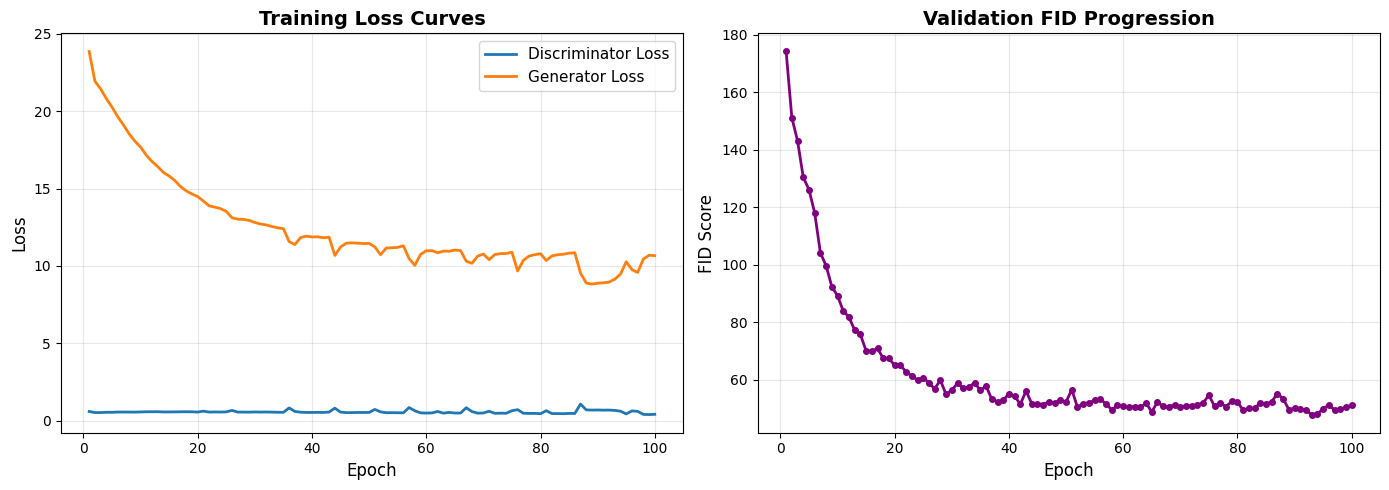

Final FID: 51.1083
Best FID: 47.7891


In [23]:
# Read training log
import pandas as pd

log_df = pd.read_csv(log_file)
epochs = log_df["epoch"].values
d_loss = log_df["d_loss"].values
g_loss = log_df["g_loss"].values
fid = log_df["fid"].values

# Plot 1: Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, d_loss, label="Discriminator Loss", linewidth=2)
axes[0].plot(epochs, g_loss, label="Generator Loss", linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Loss", fontsize=12)
axes[0].set_title("Training Loss Curves", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot 2: FID Progression
axes[1].plot(epochs, fid, marker="o", linewidth=2, markersize=4, color="purple")
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("FID Score", fontsize=12)
axes[1].set_title("Validation FID Progression", fontsize=14, fontweight="bold")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final FID: {fid[-1]:.4f}")
print(f"Best FID: {fid.min():.4f}")


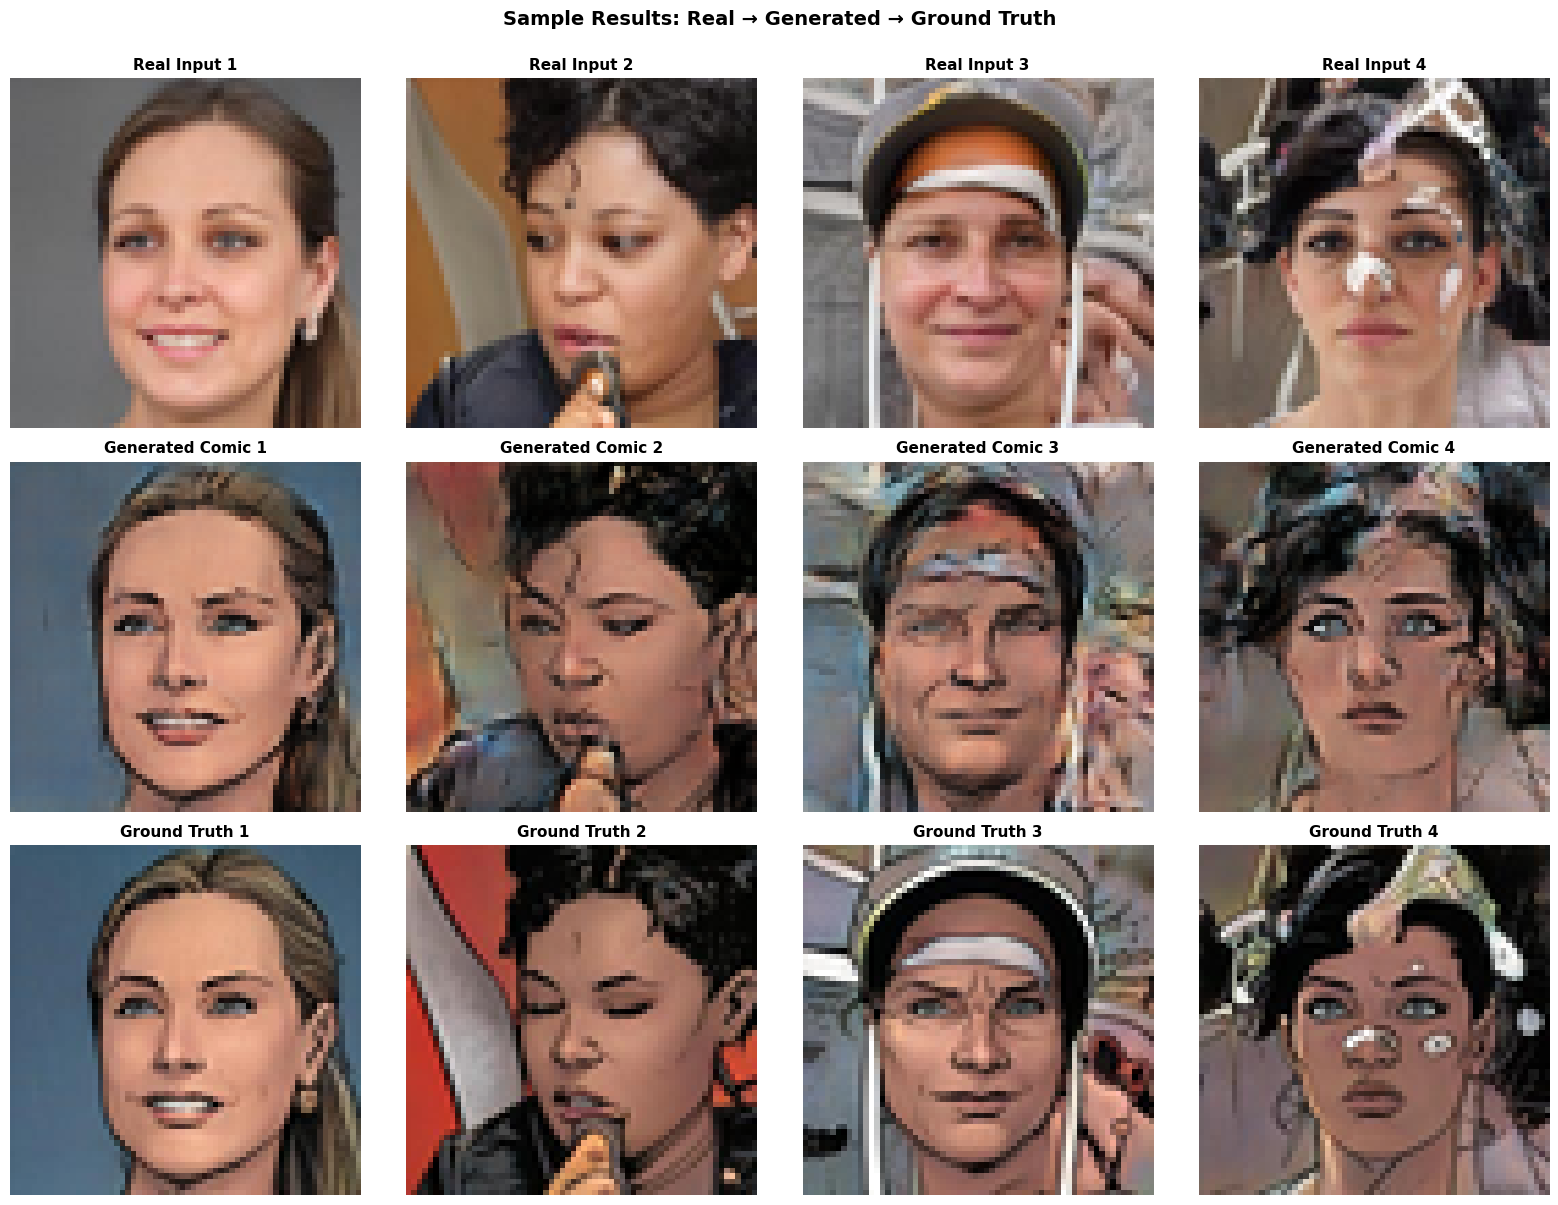

✓ Sample visualization complete


In [24]:
# Visualize sample outputs
def tensor_to_image(t):
    """Convert tensor [-1, 1] to numpy [0, 1]."""
    return ((t + 1.0) / 2.0).cpu().detach().clamp(0, 1).permute(1, 2, 0).numpy()

gen_full.eval()
sample_batch_real, sample_batch_comic = next(iter(val_loader_full))
sample_batch_real = sample_batch_real.to(DEVICE)

with torch.no_grad():
    sample_batch_fake = gen_full(sample_batch_real)

# Display 4 samples
n_display = min(4, len(sample_batch_real))
fig, axes = plt.subplots(3, n_display, figsize=(4 * n_display, 12))

for i in range(n_display):
    real_img = tensor_to_image(sample_batch_real[i])
    fake_img = tensor_to_image(sample_batch_fake[i])
    comic_img = tensor_to_image(sample_batch_comic[i])
    
    axes[0, i].imshow(real_img)
    axes[0, i].set_title(f"Real Input {i+1}", fontsize=11, fontweight="bold")
    axes[0, i].axis("off")
    
    axes[1, i].imshow(fake_img)
    axes[1, i].set_title(f"Generated Comic {i+1}", fontsize=11, fontweight="bold")
    axes[1, i].axis("off")
    
    axes[2, i].imshow(comic_img)
    axes[2, i].set_title(f"Ground Truth {i+1}", fontsize=11, fontweight="bold")
    axes[2, i].axis("off")

fig.suptitle("Sample Results: Real → Generated → Ground Truth", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

print("✓ Sample visualization complete")


## 8. Summary & Model Export

In [25]:
print("\n" + "="*70)
print("TRAINING SUMMARY")
print("="*70)

print("\n📊 HYPERPARAMETER TUNING (Grid Search)")
print("-" * 70)
print(f"Total configurations tested: 27")
print(f"Grid search results: {GRID_RESULTS_FILE}")

grid_df = pd.read_csv(GRID_RESULTS_FILE)
print(f"\nTop 5 configurations by FID:")
print(grid_df.nsmallest(5, "final_fid")[["config_idx", "learning_rate", "batch_size", "lambda_l1", "final_fid"]])

print("\n🏆 BEST CONFIGURATION (from grid search)")
print("-" * 70)
print(f"Learning Rate: {BEST_LR:.0e}")
print(f"Batch Size: {BEST_BATCH_SIZE}")
print(f"Lambda L1: {BEST_LAMBDA_L1:.0f}")

print("\n📈 FULL TRAINING RESULTS")
print("-" * 70)
print(f"Epochs: {FULL_TRAINING_EPOCHS}")
print(f"Final Discriminator Loss: {d_loss[-1]:.6f}")
print(f"Final Generator Loss: {g_loss[-1]:.6f}")
print(f"Final FID Score: {fid[-1]:.4f}")
print(f"Best FID Score: {best_val_fid:.4f} (epoch {epochs[fid.argmin()]})")

print("\n💾 CHECKPOINTS & LOGS")
print("-" * 70)
print(f"Checkpoint directory: {CHECKPOINT_DIR}")
print(f"Best model: {best_model_path}")
print(f"Training log: {log_file}")
print(f"Grid search log: {GRID_RESULTS_FILE}")

# List all checkpoints
checkpoints = sorted(CHECKPOINT_DIR.glob("pix2pix*.pt"))
print(f"\nTotal checkpoints saved: {len(checkpoints)}")
for ckpt in checkpoints[-3:]:  # Show last 3
    size_mb = ckpt.stat().st_size / (1024 * 1024)
    print(f"  - {ckpt.name} ({size_mb:.1f} MB)")

print("\n" + "="*70)
print("✓ Training pipeline complete!")
print("="*70)

# Save summary to JSON
summary = {
    "hyperparameter_tuning": {
        "total_configs": 27,
        "grid_search_file": str(GRID_RESULTS_FILE),
    },
    "best_configuration": {
        "learning_rate": float(BEST_LR),
        "batch_size": int(BEST_BATCH_SIZE),
        "lambda_l1": float(BEST_LAMBDA_L1),
    },
    "full_training": {
        "epochs": FULL_TRAINING_EPOCHS,
        "final_discriminator_loss": float(d_loss[-1]),
        "final_generator_loss": float(g_loss[-1]),
        "final_fid": float(fid[-1]),
        "best_fid": float(best_val_fid),
        "best_epoch": int(epochs[fid.argmin()]),
    },
    "artifacts": {
        "best_model": str(best_model_path),
        "checkpoint_dir": str(CHECKPOINT_DIR),
        "training_log": str(log_file),
        "grid_search_log": str(GRID_RESULTS_FILE),
    },
}

summary_file = LOG_DIR / "training_summary.json"
with open(summary_file, "w") as f:
    json.dump(summary, f, indent=2)

print(f"\n✓ Summary saved to: {summary_file}")



TRAINING SUMMARY

📊 HYPERPARAMETER TUNING (Grid Search)
----------------------------------------------------------------------
Total configurations tested: 27
Grid search results: ..\logs\grid_search_results.csv

Top 5 configurations by FID:
   config_idx  learning_rate  batch_size  lambda_l1  final_fid
7           8         0.0005          64        100   163.3205
8           9         0.0005          64        150   169.0036
4           5         0.0002          64        100   179.0541
5           6         0.0002          64        150   183.2123
6           7         0.0005          64         50   186.2589

🏆 BEST CONFIGURATION (from grid search)
----------------------------------------------------------------------
Learning Rate: 5e-04
Batch Size: 64
Lambda L1: 100

📈 FULL TRAINING RESULTS
----------------------------------------------------------------------
Epochs: 100
Final Discriminator Loss: 0.413860
Final Generator Loss: 10.665950
Final FID Score: 51.1083
Best FID Score: 

## 9. Inference: Load & Use Best Model

In [ ]:
def load_best_model(checkpoint_path: Path = None):
    """Load the best generator model for inference.
    
    Args:
        checkpoint_path: Path to checkpoint file. If None, uses best_model_path from training.
    
    Returns:
        Generator model in eval mode on device.
    """
    if checkpoint_path is None:
        checkpoint_path = best_model_path
    
    gen_infer = Generator().to(DEVICE)
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    gen_infer.load_state_dict(ckpt["gen_state_dict"])
    gen_infer.eval()
    return gen_infer


def infer_single_image(image_path: Path, model = None):
    """Generate comic-style version of a real face image.
    
    Args:
        image_path: Path to input image (real face).
        model: Generator model. If None, loads best model.
    
    Returns:
        Tuple of (input_image, output_image) as numpy arrays [0, 1].
    """
    if model is None:
        model = load_best_model()
    
    # Load and preprocess image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)
    img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 127.5 - 1.0
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)
    
    # Generate comic version
    with torch.no_grad():
        comic_tensor = model(img_tensor)
    
    # Convert back to image format
    input_img = tensor_to_image(img_tensor[0])
    output_img = tensor_to_image(comic_tensor[0])
    
    return input_img, output_img


# Load best model
print("Loading best model for inference...")
best_gen = load_best_model()
print(f"✓ Best generator loaded from: {best_model_path}")

# Test inference on one validation image
print("\nTesting inference on a validation image...")
val_real_files = sorted([f for f in VAL_REAL_DIR.iterdir() if f.suffix.lower() in IMG_EXTENSIONS])

if len(val_real_files) > 0:
    test_image = val_real_files[0]
    input_img, output_img = infer_single_image(test_image, best_gen)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(input_img)
    axes[0].set_title("Input: Real Face", fontsize=12, fontweight="bold")
    axes[0].axis("off")
    
    axes[1].imshow(output_img)
    axes[1].set_title("Output: Comic Face", fontsize=12, fontweight="bold")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Inference successful on: {test_image.name}")

print("\n✓ Ready for inference! Use load_best_model() and infer_single_image() functions.")
